In [1]:
import os
import kagglehub
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Sequential, layers, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from PIL import Image
import cv2


In [2]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "preetviradiya/brian-tumor-dataset"
)
print(path)

data/kagglehub_cache\datasets\preetviradiya\brian-tumor-dataset\versions\1


In [3]:
def load_images_from_folders(root_path):
    images = []
    labels = []

    class_map = {
        "Brain Tumor": 1,
        "Healthy": 0
    }

    for class_name, label in class_map.items():
        class_path = os.path.join(root_path, class_name)
        for file in os.listdir(class_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff')):
                img_path = os.path.join(class_path, file)

                try:
                    img = Image.open(img_path)
                    img = img.convert("RGB")
                    img = img.resize((128, 128))
                    img_array = np.array(img)
                    if img_array.dtype == np.uint16:
                        img_array = img_array.astype(np.float32) / 65535.0
                    else:
                        img_array = img_array.astype(np.float32) / 255.0

                    images.append(img_array)
                    labels.append(label)

                except Exception as e:
                    print(f"Ошибка: {file} -> {e}")

    return np.array(images), np.array(labels)

In [5]:
root_path = Path(path) / "Brain Tumor Data Set" / "Brain Tumor Data Set"
X, Y = load_images_from_folders(
    root_path=root_path
)

print(X.shape)
print(Y.shape)

sss = StratifiedShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(sss.split(X, Y))

x_train, x_test = X[train_idx], X[test_idx]
y_train, y_test = Y[train_idx].astype(np.float32), Y[test_idx].astype(np.float32)

(4600, 128, 128, 3)
(4600,)


In [6]:
def check_class_balance(labels, name):
    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n{name} распределение:")
    for u, c in zip(unique, counts):
        class_name = "Healhty (0)" if u == 0 else "Brain Tumor (1)"
        percent = (c / len(labels)) * 100
        print(f"{class_name}: {c} изображений ({percent:.2f}%)")

check_class_balance(y_train, "Train выборка")
check_class_balance(y_test, "Test выборка")


Train выборка распределение:
Healhty (0): 1670 изображений (45.38%)
Brain Tumor (1): 2010 изображений (54.62%)

Test выборка распределение:
Healhty (0): 417 изображений (45.33%)
Brain Tumor (1): 503 изображений (54.67%)


In [29]:
import tensorflow as tf
from tensorflow.keras import layers, Model

PATCH_SIZE = 16
NUM_PATCHES = (128 // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 4


class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )

        batch_size = tf.shape(images)[0]
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches  # ← ВАЖНО
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)  # ← FIX
        return self.projection(patch) + self.position_embedding(positions)


def create_vit_visualizer():
    inputs = layers.Input(shape=(128, 128, 3))

    patches = Patches(PATCH_SIZE)(inputs)
    encoded = PatchEncoder(NUM_PATCHES, PROJECTION_DIM)(patches)

    attentions = []

    for _ in range(TRANSFORMER_LAYERS):
        x1 = layers.LayerNormalization()(encoded)

        attn_layer = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=PROJECTION_DIM
        )

        _, attn_scores = attn_layer(x1, x1, return_attention_scores=True)
        attentions.append(attn_scores)

        x2 = attn_layer(x1, x1)
        encoded = layers.Add()([x2, encoded])

    return Model(inputs, attentions)


vit_model = create_vit_visualizer()

In [30]:
def get_vit_attention_map(vit_model, img_array):
    attentions = vit_model.predict(img_array)

    attn = attentions[-1][0]  # (heads, tokens, tokens)
    attn = np.mean(attn, axis=0)

    # ❗ УБИРАЕМ CLS-логику
    attn_map = np.mean(attn, axis=0)  # агрегируем внимание

    size = int(np.sqrt(len(attn_map)))
    attention_map = attn_map.reshape(size, size)

    return attention_map

In [31]:
import cv2
import matplotlib.pyplot as plt


def visualize_vit_overlay(img, attention_map):
    attention_map = cv2.resize(
        attention_map,
        (128, 128),
        interpolation=cv2.INTER_NEAREST
    )

    attention_map = attention_map / (attention_map.max() + 1e-8)

    heatmap = np.uint8(255 * attention_map)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    img_uint8 = np.uint8(img * 255)

    alpha = 0.4
    overlay = heatmap * alpha + img_uint8 * (1 - alpha)
    overlay = np.uint8(overlay)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("MRI")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(attention_map, cmap='jet')
    plt.title("ViT Attention")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


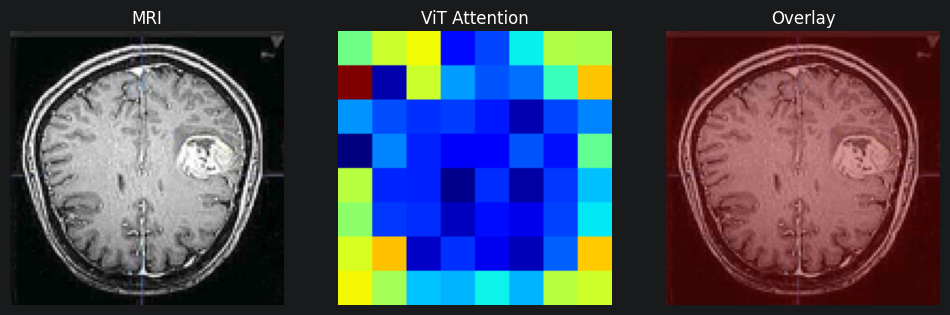

In [32]:
def load_and_preprocess_single_image(img_path):
    img = Image.open(img_path)
    img = img.convert("RGB")
    img = img.resize((128, 128))
    img_array = np.array(img)

    if img_array.dtype == np.uint16:
        img_array = img_array.astype(np.float32) / 65535.0
    else:
        img_array = img_array.astype(np.float32) / 255.0

    return img_array


img_path = "data/kagglehub_cache/datasets/preetviradiya/brian-tumor-dataset/versions/1/Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (1300).jpg"

img = load_and_preprocess_single_image(img_path)
img_array = np.expand_dims(img, axis=0)

attention_map = get_vit_attention_map(vit_model, img_array)

visualize_vit_overlay(img, attention_map)